# 🧪 Fertilizer Recommendation Model Training

This notebook was programmatically generated and aligned with the backend model specifications.

## 1. Imports and Setup


In [1]:
import pandas as pd
import numpy as np
import pickle
import os
from sklearn.tree import DecisionTreeClassifier
print('Libraries loaded!')


Libraries loaded!


## 2. Load Dataset


In [2]:
df = pd.read_csv('../datasets/Fertilizer_Prediction.csv')
print(f'Shape: {df.shape}')
df.head(5)


Shape: (99, 9)


,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26,52,38,Sandy,Maize,37,0,0,Urea
1,29,52,45,Loamy,Sugarcane,12,0,36,DAP
2,34,65,62,Black,Cotton,7,9,30,14-35-14
3,32,62,34,Red,Tobacco,22,0,20,28-28
4,28,54,46,Clayey,Paddy,35,0,0,Urea


## 3. Preprocessing & Stage Simulation


In [3]:
np.random.seed(42)
stages = ["Sowing", "Vegetative", "Flowering", "Harvesting"]
df['Stage'] = np.random.choice(stages, size=len(df))

crop_map_dataset = {
    'Paddy': 0, 'Rice': 0, 'Maize': 1, 'Cotton': 2, 'Chickpea': 3, 
    'Pigeon Peas': 4, 'Groundnut': 5, 'Wheat': 0, 'Sugarcane': 1, 
    'Barley': 1, 'Tobacco': 2, 'Oil seeds': 5, 'Pulses': 4, 'Millets': 1
}
df['crop_encoded'] = df['Crop Type'].map(crop_map_dataset).fillna(0).astype(int)

soil_map_dataset = {'Red': 0, 'Black': 1, 'Alluvial': 2, 'Clay': 3, 'Sandy': 4, 'Loamy': 5}
df['soil_encoded'] = df['Soil Type'].map(soil_map_dataset).fillna(5).astype(int)

stage_map_dataset = {"Sowing": 0, "Vegetative": 1, "Flowering": 2, "Harvesting": 3}
df['stage_encoded'] = df['Stage'].map(stage_map_dataset).fillna(0).astype(int)

fert_name_map = {
    'Urea': 0, 'DAP': 1, 'MOP': 2, '10-26-26': 3, '20-20': 4, '28-28': 4, '14-35-14': 3, '17-17-17': 4
}
df['fert_encoded'] = df['Fertilizer Name'].map(fert_name_map).fillna(4).astype(int)

X = df[['crop_encoded', 'soil_encoded', 'Nitrogen', 'Phosphorous', 'Potassium', 'stage_encoded']].values
y = df['fert_encoded'].values
print(f'Features shape: {X.shape}, Targets: {len(np.unique(y))}')


Features shape: (99, 6), Targets: 4


## 4. Model Training


In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)
print('Decision Tree trained!')


Decision Tree trained!


## 5. Evaluation Metrics & Confusion Matrix Heatmap


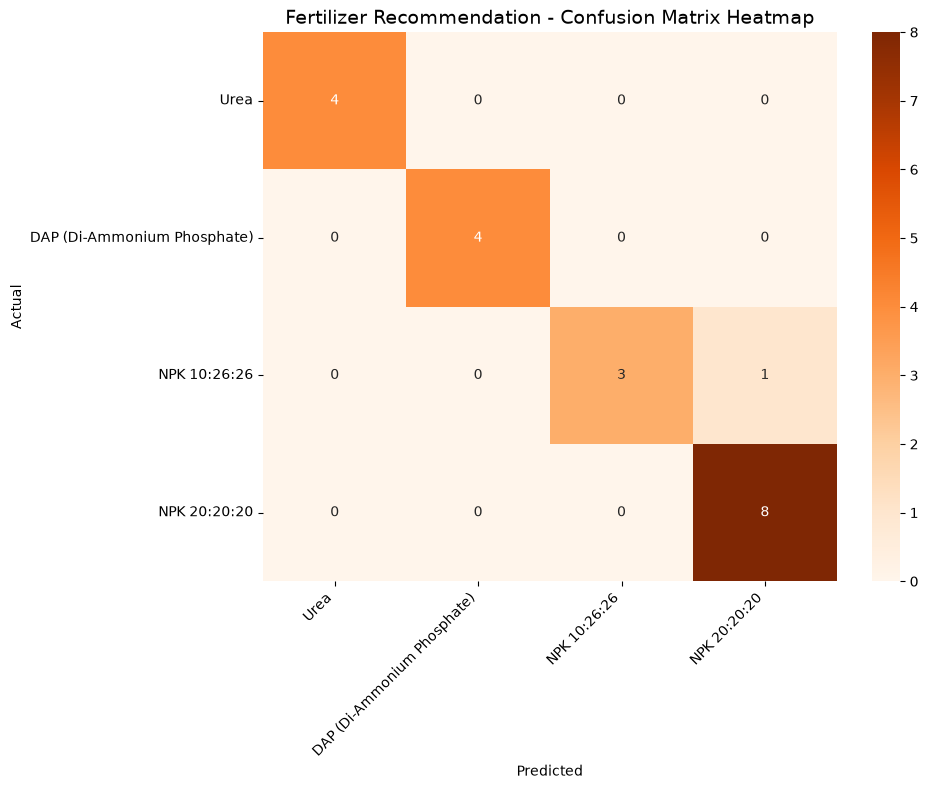

FERTILIZER CLASSIFICATION REPORT
                             precision    recall  f1-score   support

                       Urea       1.00      1.00      1.00         4
DAP (Di-Ammonium Phosphate)       1.00      1.00      1.00         4
               NPK 10:26:26       1.00      0.75      0.86         4
               NPK 20:20:20       0.89      1.00      0.94         8

                   accuracy                           0.95        20
                  macro avg       0.97      0.94      0.95        20
               weighted avg       0.96      0.95      0.95        20



In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

labels = ["Urea", "DAP (Di-Ammonium Phosphate)", "MOP (Muriate of Potash)", 
          "NPK 10:26:26", "NPK 20:20:20", "Ammonium Sulphate", 
          "SSP (Single Super Phosphate)", "Zinc Sulphate"]

unique_y = np.unique(np.concatenate([y_test, dt_model.predict(X_test)]))
display_labels = [labels[i] for i in unique_y]

cm = confusion_matrix(y_test, dt_model.predict(X_test))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=display_labels, yticklabels=display_labels)
plt.title('Fertilizer Recommendation - Confusion Matrix Heatmap', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fertilizer_confusion_matrix.png', dpi=150)
plt.show()

print("="*60)
print("FERTILIZER CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, dt_model.predict(X_test), target_names=display_labels))


## 6. Save Model Files


In [6]:
os.makedirs('../../ml_models', exist_ok=True)
with open('../../ml_models/fertilizer_recommendation.pkl', 'wb') as f:
    pickle.dump(dt_model, f)
print('Successfully saved fertilizer model!')


Successfully saved fertilizer model!
